# Retail Sales Data Analysis

## Oasis Infobyte Data Analytics Internship

### Exploratory Data Analysis (EDA)

## 1. Import Libraries

In [26]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [28]:
# Load dataset

df = pd.read_csv("../data/retail_sales_dataset.csv")

# Display first five rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [105]:
# Display all column names

df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Quarter', 'Age Group'],
      dtype='object')

### Dataset Shape

In [30]:
# Check number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 9


### Dataset Information

In [32]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### Data Types

In [34]:
# Check data types

df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

### Missing Values

In [36]:
# Check missing values

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Duplicate Records

In [38]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 3. Data Preparation

### Convert Date Column

In [40]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(df["Date"])

# Check data type
df["Date"].dtype

dtype('<M8[ns]')

### Create Time Features

In [42]:
# Create month and quarter columns

df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2


### Create Age Groups

In [44]:
# Create age groups

bins = [17, 24, 34, 44, 54, 64, 100]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df["Age Group"].value_counts().sort_index()

Age Group
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
65+        0
Name: count, dtype: int64

## 4. Descriptive Statistics

In [52]:
# Select numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns

# Calculate descriptive statistics

summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

summary

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## 5. Sales Trend Analysis

### Monthly Sales Trend

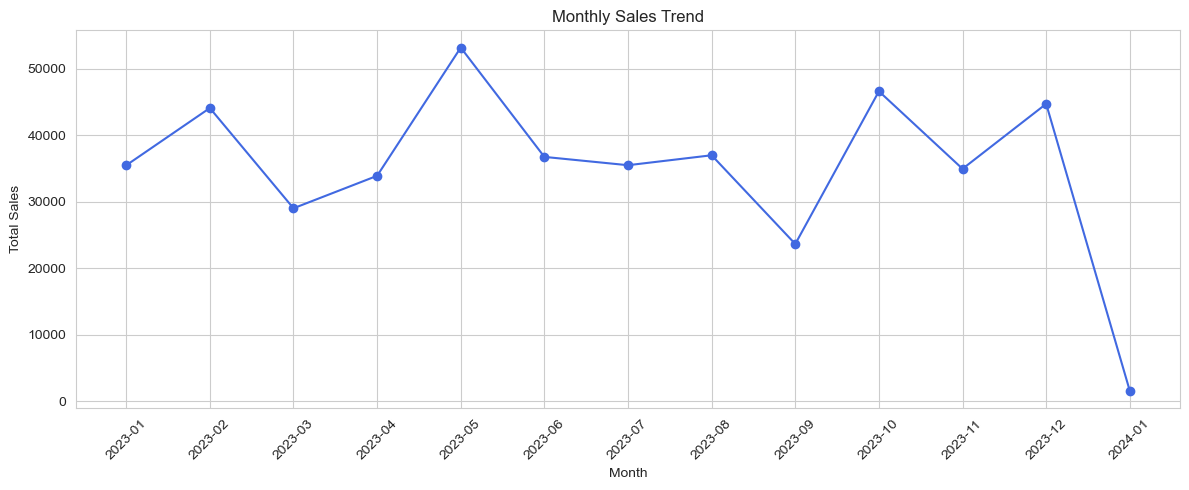

In [58]:
# Calculate monthly sales

monthly_sales = df.groupby("Month")["Total Amount"].sum()

# Plot monthly sales

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    color="royalblue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Quarterly Sales Trend

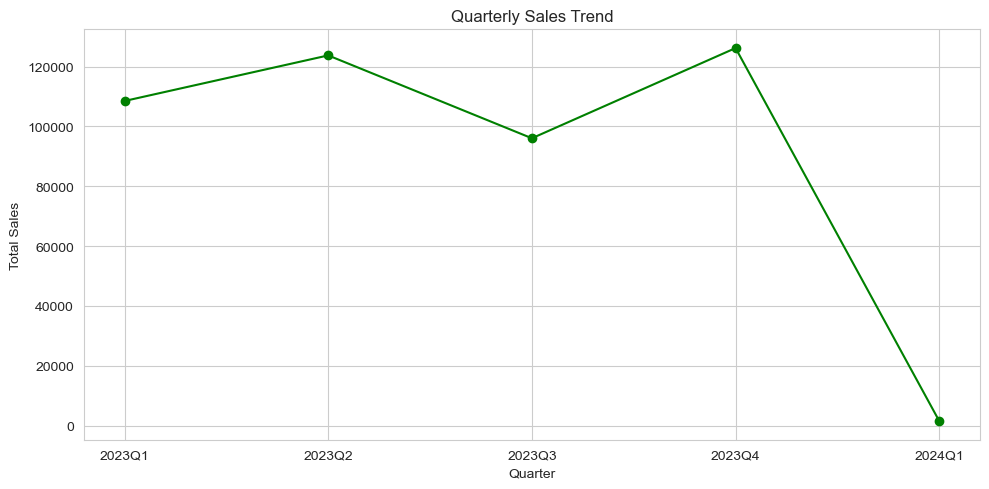

In [68]:
# Calculate quarterly sales

quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

# Plot quarterly sales

plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o",
    color="green"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

## 6. Customer Demographics

### Age Group Distribution

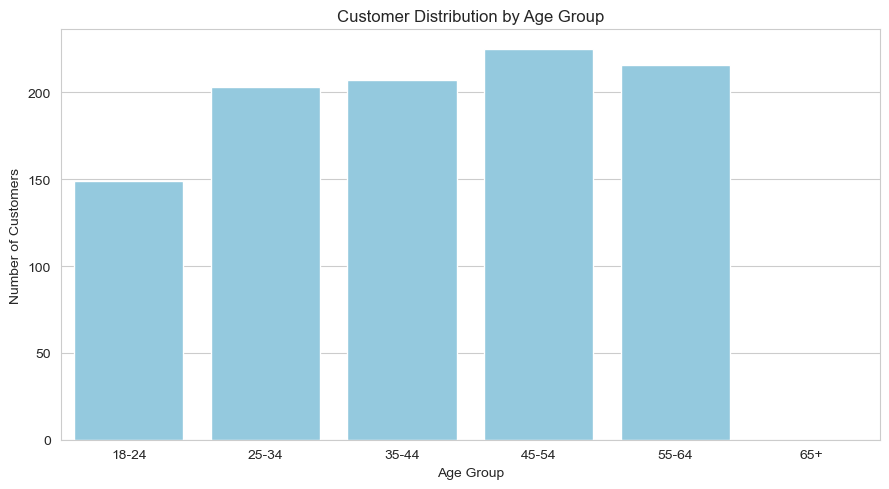

In [70]:
# Count customers by age group

age_counts = df["Age Group"].value_counts().sort_index()

# Plot age group distribution

plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    color="skyblue"
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Gender Distribution

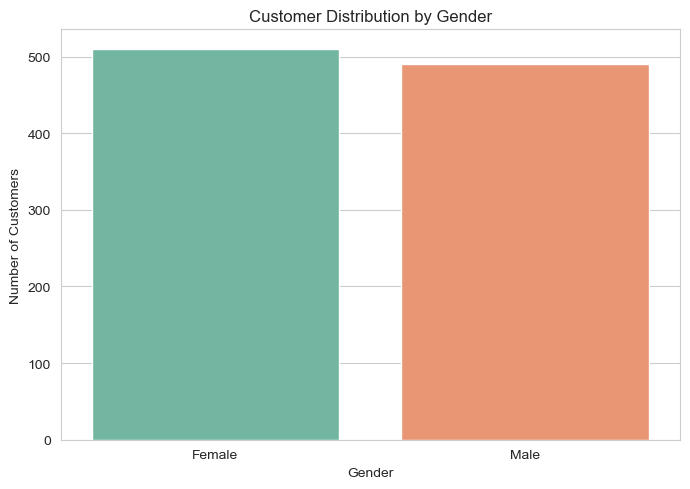

In [72]:
# Count customers by gender

gender_counts = df["Gender"].value_counts()

# Plot gender distribution

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    hue=gender_counts.index,
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Top 10 Best-Selling Products

The dataset does not contain individual product names or product IDs.
Therefore, product-level Top 10 analysis cannot be performed.

Instead, product performance is analysed at the Product Category level
using revenue and quantity sold.sold.

## 8. Correlation Analysis

### Correlation Heatmap

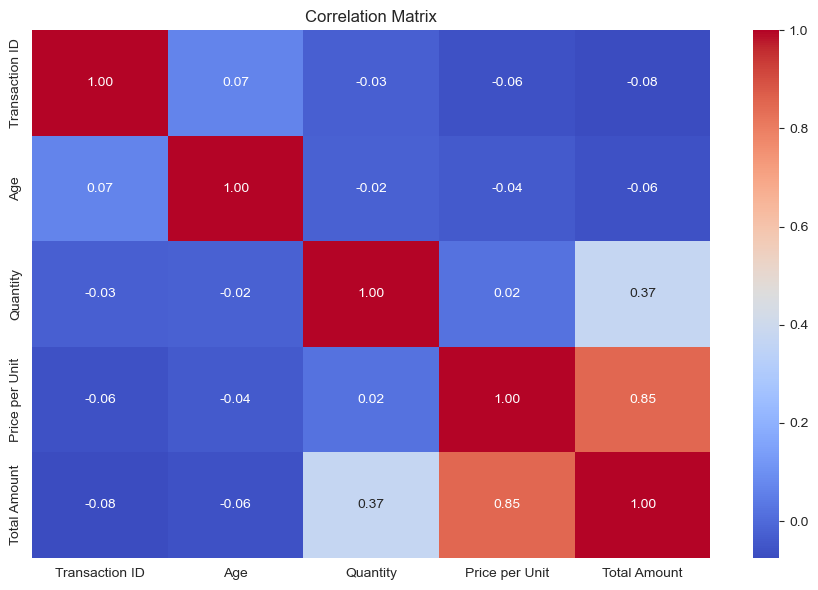

In [99]:
# Calculate correlation matrix

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

# Plot correlation heatmap

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 9. Additional Analysis

### Sales by Gender and Product Category

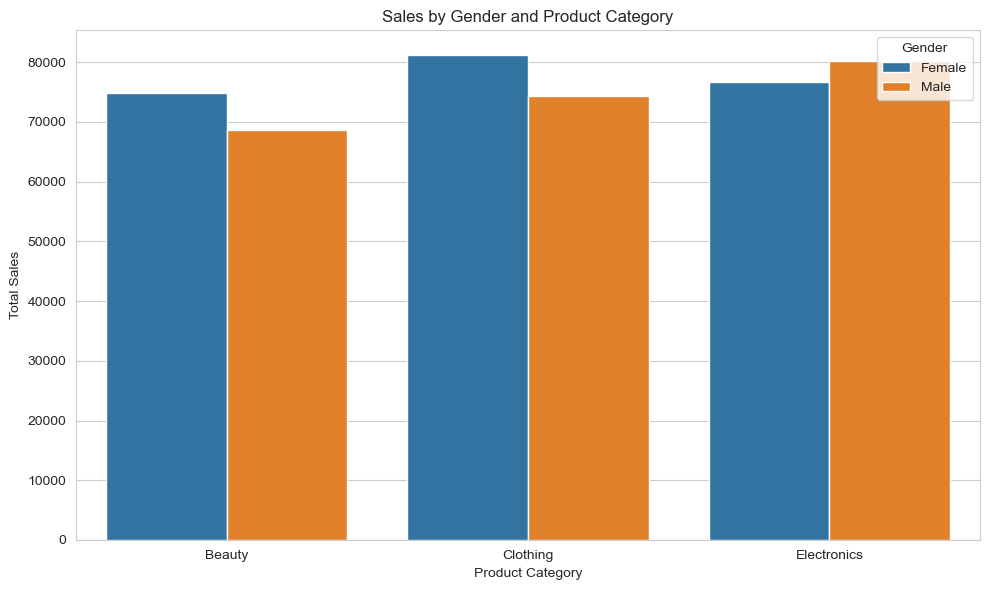

In [101]:
# Calculate sales by gender and category

gender_category_sales = (
    df.groupby(
        ["Gender", "Product Category"],
        observed=True
    )["Total Amount"]
    .sum()
    .reset_index()
)

# Plot sales comparison

plt.figure(figsize=(10, 6))

sns.barplot(
    data=gender_category_sales,
    x="Product Category",
    y="Total Amount",
    hue="Gender"
)

plt.title("Sales by Gender and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

## 10. Business Recommendations

1. Focus marketing campaigns on high-performing customer groups.

2. Increase promotional activities for high-revenue product categories.

3. Use monthly and quarterly sales trends for inventory and marketing plannng.


## 11. Conclusion

The analysis provided insights into sales trends, customer demographics,
and product category performance.

The findings can be used to improve marketing strategies, inventory
planning, and overall business decision-making.

## Save Outputs

### Save Descriptive Statistics

In [33]:
# Save descriptive statistics

summary.to_csv(
    "../output/tables/descriptive_statistics.csv",
    index=True
)

print("File saved successfully!")

File saved successfully!


### Save Age Group Distribution

In [39]:
# Save age group distribution

plt.savefig(
    "../output/figures/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Age group distribution saved successfully!")

<Figure size 640x480 with 0 Axes>

Age group distribution saved successfully!


### Save Gender Distribution

In [41]:
# Save gender distribution

plt.savefig(
    "../output/figures/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gender distribution saved successfully!")

<Figure size 640x480 with 0 Axes>

Gender distribution saved successfully!


### Save Revenue by Product Category

In [43]:
# Save revenue by product category

plt.savefig(
    "../output/figures/category_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Category revenue chart saved successfully!")

<Figure size 640x480 with 0 Axes>

Category revenue chart saved successfully!


### Save Correlation Heatmap

In [52]:
# Save correlation heatmap

plt.savefig(
    "../output/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correlation heatmap saved successfully!")

<Figure size 640x480 with 0 Axes>

Correlation heatmap saved successfully!


### Save Sales by Gender and Product Category

In [54]:
# Save gender and product category sales chart

plt.savefig(
    "../output/figures/gender_category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gender-category sales chart saved successfully!")

<Figure size 640x480 with 0 Axes>

Gender-category sales chart saved successfully!


### Save Monthly Sales Trend

In [56]:
# Save monthly sales trend

plt.savefig(
    "../output/figures/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Monthly sales trend saved successfully!")

<Figure size 640x480 with 0 Axes>

Monthly sales trend saved successfully!


### Save Quarterly Sales Trend

In [58]:
# Save quarterly sales trend

plt.savefig(
    "../output/figures/quarterly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Quarterly sales trend saved successfully!")

<Figure size 640x480 with 0 Axes>

Quarterly sales trend saved successfully!
